Learning rate: 0.0001 RMSE: 0.1737343456436653
Learning rate: 0.001 RMSE: 0.15079211829757178
Learning rate: 0.01 RMSE: 0.26100237320133335
RMSE Ridge: 1.37669544358274
RMSE Lasso: 1.2188185567783965


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.521e-01, tolerance: 1.084e-03
  model = cd_fast.enet_coordinate_descent(


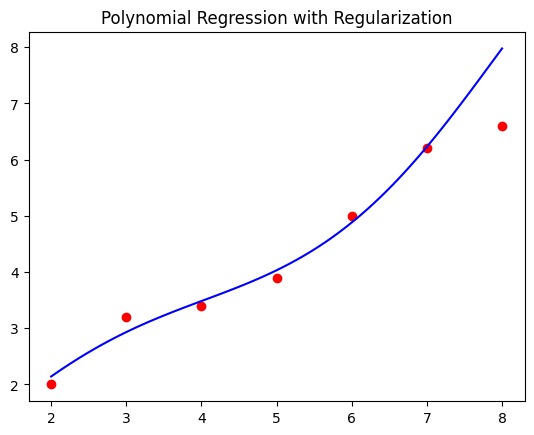

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Data
x = np.array([2,3,4,5,6,7,8]).reshape(-1,1)
y = np.array([2,3.2,3.4,3.9,5,6.2,6.6])

# Train/Test split
x_train, x_test = x[:6], x[6:]
y_train, y_test = y[:6], y[6:]

# 1️⃣ Linear Regression với nhiều learning rate
learning_rates = [0.0001,0.001,0.01]

for lr in learning_rates:
    model = SGDRegressor(learning_rate='constant', eta0=lr, max_iter=1000)
    model.fit(x_train,y_train)

    pred = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test,pred))

    print("Learning rate:",lr,"RMSE:",rmse)


# 2️⃣ Polynomial Regression + Regularization (bài 3.b)
poly = PolynomialFeatures(degree=5)

X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.transform(x_test)

ridge = Ridge(alpha=0.1)
lasso = Lasso(alpha=0.1)

ridge.fit(X_train_poly,y_train)
lasso.fit(X_train_poly,y_train)

pred_ridge = ridge.predict(X_test_poly)
pred_lasso = lasso.predict(X_test_poly)

print("RMSE Ridge:",np.sqrt(mean_squared_error(y_test,pred_ridge)))
print("RMSE Lasso:",np.sqrt(mean_squared_error(y_test,pred_lasso)))


# 3️⃣ Visualization
x_plot = np.linspace(2,8,100).reshape(-1,1)
X_plot = poly.transform(x_plot)

y_plot = ridge.predict(X_plot)

plt.scatter(x,y,color='red')
plt.plot(x_plot,y_plot,color='blue')
plt.title("Polynomial Regression with Regularization")
plt.show()